<a href="https://colab.research.google.com/github/Sreeja0522/ML-Project-Pneumoia-detection-CNN/blob/main/Pneumonia_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow opencv-python matplotlib

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [4]:
# Download the dataset (Zip file)
!wget https://data.mendeley.com/public-files/datasets/rscbjbr9sj/files/f12e800d-58dc-4375-9273-516ba42c161a/file_downloaded -O pneumonia_dataset.zip



--2026-04-07 08:49:01--  https://data.mendeley.com/public-files/datasets/rscbjbr9sj/files/f12e800d-58dc-4375-9273-516ba42c161a/file_downloaded
Resolving data.mendeley.com (data.mendeley.com)... 162.159.133.86, 162.159.130.86
Connecting to data.mendeley.com (data.mendeley.com)|162.159.133.86|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1177 (1.1K) [application/json]
Saving to: ‘pneumonia_dataset.zip’

pneumonia_dataset.z 100%[===================>]   1.15K  --.-KB/s    in 0s      

2026-04-07 08:49:01 (81.1 MB/s) - ‘pneumonia_dataset.zip’ saved [1177/1177]



In [6]:
import json
import os

# Create the directory
!mkdir -p ~/.kaggle

# Write your credentials to the file
data = {"username":"YOUR_KAGGLE_USERNAME","key":"9f71525d531958f246b41123e53348f8"}
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(data, f)

# Set permissions so the API doesn't complain
!chmod 600 ~/.kaggle/kaggle.json

# Test the connection
!kaggle datasets list -s "chest xray"

ref                                                             title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  -------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
bachrr/covid-chest-xray                                         COVID-19 chest xray                                  252641948  2020-05-15 00:30:50.877000          14438        254  0.9411765        
nikhilpandey360/chest-xray-masks-and-labels                     Chest Xray Masks and Labels                        10281955076  2019-01-21 09:11:43.557000          25239        214  0.75             
alifrahman/chestxraydataset                                     chest-xray-dataset                                  1222937573  2020-08-31 19:36:35.387000           4226         35  0.625            


In [7]:
# Download the standard Pneumonia vs Normal dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

# Unzip into a folder named 'data'
import zipfile
with zipfile.ZipFile('chest-xray-pneumonia.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

print("Dataset is ready!")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:18<00:00, 135MB/s] 

Dataset is ready!


In [8]:
import os

def list_files(startpath):
    for root, dirs, files in os.walk(startpath):
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        # Only show the first 2 files in each folder to keep it clean
        for f in files[:2]:
            print(f'{subindent}{f}')
        if len(files) > 2:
            print(f'{subindent}... ({len(files)} total files)')
        if level > 1: # Limit depth so it doesn't print thousands of images
            dirs[:] = []

list_files('data')

data/
    chest_xray/
        val/
        test/
        chest_xray/
            .DS_Store
        train/
        __MACOSX/
            ._chest_xray


In [9]:
import os

base_path = 'data/chest_xray'
for folder in ['train', 'test', 'val']:
    for category in ['NORMAL', 'PNEUMONIA']:
        path = os.path.join(base_path, folder, category)
        if os.path.exists(path):
            print(f"{folder}/{category}: {len(os.listdir(path))} images")

train/NORMAL: 1341 images
train/PNEUMONIA: 3875 images
test/NORMAL: 234 images
test/PNEUMONIA: 390 images
val/NORMAL: 8 images
val/PNEUMONIA: 8 images


In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Define Augmentation + Validation Split (20% of training data for validation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2 # This creates a better validation set from your 5,000+ images
)

# 2. Test set stays separate for the final exam
test_datagen = ImageDataGenerator(rescale=1./255)

# 3. Training Set
train_set = train_datagen.flow_from_directory(
    'data/chest_xray/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training' # Use the 80% for training
)

# 4. Validation Set (The 20% we split off)
val_set = train_datagen.flow_from_directory(
    'data/chest_xray/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation' # Use the 20% for validation
)

# 5. Final Test Set
test_set = test_datagen.flow_from_directory(
    'data/chest_xray/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Initialize the model
model = Sequential()

# 1. First Convolutional Layer
# Detects simple patterns (edges/lines)
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 2. Second Convolutional Layer
# Detects more complex shapes (lung boundaries)
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 3. Third Convolutional Layer
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 4. Flattening
# Converts 2D feature maps into a 1D vector for the final decision
model.add(Flatten())

# 5. Fully Connected (Dense) Layers
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))  # Prevents memorization (overfitting)
model.add(Dense(1, activation='sigmoid')) # Output: 0 (Normal) or 1 (Pneumonia)

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Standard Keras progress bar (very reliable)
history = model.fit(
    train_set,
    validation_data=val_set,
    epochs=10,
    steps_per_epoch=len(train_set),
    validation_steps=len(val_set),
    verbose=1
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 112s 794ms/step - accuracy: 0.8435 - loss: 0.3707 - val_accuracy: 0.8639 - val_loss: 0.4218
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 128s 733ms/step - accuracy: 0.8936 - loss: 0.2720 - val_accuracy: 0.8965 - val_loss: 0.2450
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 96s 734ms/step - accuracy: 0.9053 - loss: 0.2383 - val_accuracy: 0.8888 - val_loss: 0.2455
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 96s 735ms/step - accuracy: 0.9159 - loss: 0.2140 - val_accuracy: 0.9051 - val_loss: 0.2202
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 95s 725ms/step - accuracy: 0.9202 - loss: 0.2065 - val_accuracy: 0.9147 - val_loss: 0.2061
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 96s 734ms/step - accuracy: 0.9226 - loss: 0.1940 - val_accuracy: 0.9156 - val_loss: 0.1988
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 97s 739ms/step - accuracy: 0.9274 - loss: 0.1901 - val_accuracy: 0.9291 - val_loss: 0.1847
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 140s 725ms/step - accuracy: 0.9334 - loss

In [16]:
test_loss, test_acc = model.evaluate(test_set)
print(f"Final Test Accuracy: {test_acc*100:.2f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 268ms/step - accuracy: 0.8766 - loss: 0.3515
Final Test Accuracy: 87.66%


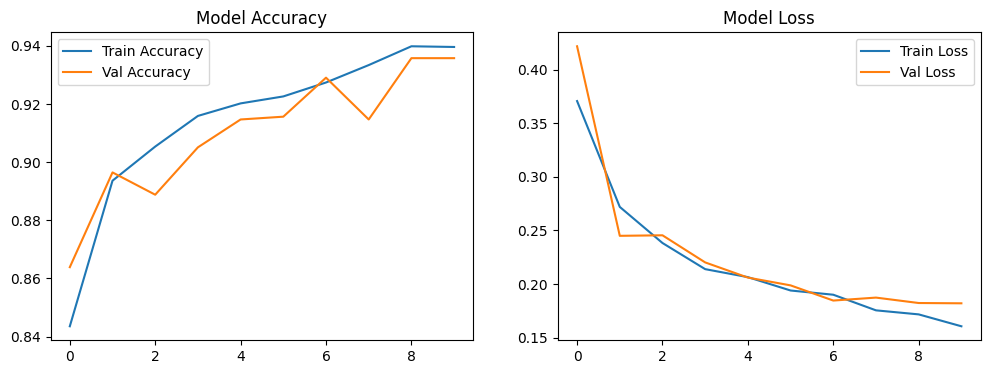

In [17]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

In [24]:
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_chest_xray(img_path):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Get prediction
    prediction = model.predict(img_array)
    confidence = prediction[0][0]

    if confidence > 0.5:
        result = "PNEUMONIA DETECTED"
        score = confidence * 100
        message = "Possible disease detected – please consult a doctor."
    else:
        result = "NORMAL"
        score = (1 - confidence) * 100
        message = "No disease detected."

    print(f"Prediction: {result}")
    print(f"Confidence: {score:.2f}%")
    print(f"Decision Support: {message}")

# Test it with a random image from the test set
sample_path = 'data/chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg'
predict_chest_xray(sample_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Prediction: NORMAL
Confidence: 55.11%
Decision Support: No disease detected.


Real-life Testing

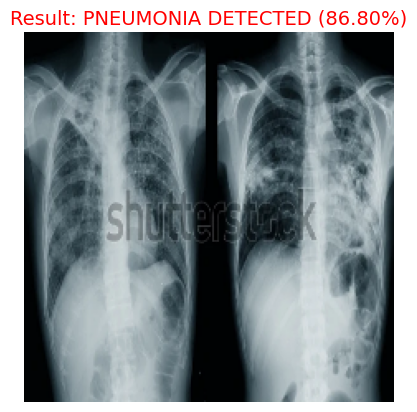

Decision Support: Possible disease detected – please consult a doctor.


In [25]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

def predict_local_image(file_path):
    # 1. Load and Preprocess (Requirement: 224x224)
    img = image.load_img(file_path, target_size=(224, 224))
    img_array = image.img_to_array(img)

    # 2. Normalize (Requirement: rescale 1./255)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # 3. Predict
    prediction = model.predict(img_array, verbose=0)
    confidence = prediction[0][0]

    # 4. Decision Logic
    if confidence > 0.5:
        result = "PNEUMONIA DETECTED"
        prob = confidence * 100
        message = "Possible disease detected – please consult a doctor."
        color = 'red'
    else:
        result = "NORMAL"
        prob = (1 - confidence) * 100
        message = "No disease detected."
        color = 'green'

    # 5. Display Output (Requirement: FRD 5.8)
    plt.imshow(img)
    plt.title(f"Result: {result} ({prob:.2f}%)", color=color, fontsize=14)
    plt.axis('off')
    plt.show()

    print(f"Decision Support: {message}")

# Use the path you provided
path_to_image = "/content/Screenshot 2026-04-07 145333.png"
predict_local_image(path_to_image)
